**Table of contents**<a id='toc0_'></a>    
- [General sampling methods](#toc1_)    
  - [Overview](#toc1_1_)    
  - [target distribution](#toc1_2_)    
    - [is the distribution log-concave](#toc1_2_1_)    
  - [Rejection sampling](#toc1_3_)    
  - [Ratio of Uniforms (RoU)](#toc1_4_)    
  - [Numerical inversion](#toc1_5_)    
      - [Hermite Inverse CDF HINV](#toc1_5_1_1_)    
      - [Polynomial inverse CDF](#toc1_5_1_2_)    
  - [Conclusion](#toc1_6_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [8]:
import os
import sys
import glob

path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(
    splitted[0] + os.sep, splitted[1], splitted[2], splitted[3]
)
src_path = os.path.join(user_independent, "GitHub", "Photoswitching")
sys.path.append(src_path)

import src.distributions as dist
import src.figure as fi

from scipy.stats import sampling
from scipy.optimize import minimize, Bounds
from scipy.stats import kstest
from scipy.stats.sampling import NumericalInverseHermite, NumericalInversePolynomial
  
import numpy as np
import inspect
from itertools import product

%load_ext autoreload
%autoreload 2

import warnings

def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache

        line = linecache.getline(filename, lineno)
    return f"WARNING for line: {line} {msg} \n"

warnings.formatwarning = custom_warning_format

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# <a id='toc1_'></a>[General sampling methods](#toc0_)
Goal: sampling from ps fingerprint distribution for data-augmentation (model generalization, improved realism) and quick data generation to later use in machine learning - what sampling methods are available to the distribution, what method is the best in this scenario \

## <a id='toc1_1_'></a>[Overview](#toc0_)
**Available traits**
- CDF
- PDF
  - monotonically decreasing
  - unimodal
  - univariate
  - convex
  - neither log-concave nor log-convex 
  - neither 1/sqrt-concave nor 1/sqrt-convex
  - support 0 to inf
  - bounded
  - first and second derivative
  - logp (does not provide numerical stability)

**Not available traits**
- quantile function (inverse CDF)

**Possibilities** 
- rejection sampling: due to known PDF
  - proposal distribution can be rescaled (such that the integral is >1), i.e., it is a hat *function* (not pdf),
- Ratio of uniforms
- numerical inverse transform sampling: can be slow, not exact
- Ziggurat algorithm: good for monotonically decreasing distributions
- MCMC (slice, metropolis or gibbs sampling): good for unimodal distributions

**Not possible**
- ARS (adaptive rejection sampling) - pdf is not log-concave
  - TransformedDensityRejection by scipy
- Simple Ratio of Uniforms (SROU) - needs pdf to be T-concave (concave after some transformation, so far only log and 1/sqrt available)
- Inverse transform sampling using quantile function

Also see
- https://statmath.wu.ac.at/software/unuran/doc/unuran.html#RVG
- https://statmath.wu.ac.at/software/unuran/doc/unuran.html#Methods_005ffor_005fCONT

## <a id='toc1_2_'></a>[target distribution](#toc0_)

In [2]:
def hypoexponential_distribution_cdf(x, *args):
    """
    CDF of the hypoexponential distribution.

    Parameters
    ----------
    x : float, 1-D array_like
        Sample.
    args : float, 1-D array_like
        Parameters (lambdas) of the hypoexponential distribution.

    Returns
    -------
    cdf : float, 1-D array_like
        CDF of the hypoexponential distribution.
    """
    cdf = 1
    for arg in args:
        other_args = np.array([other for other in args if other != arg])
        cdf -= np.exp(-arg * x) * np.prod(other_args) / np.prod(- arg + other_args)

    return cdf


def hypoexponential_distribution_pdf(x, *args):
    """
    PDF of the hypoexponential distribution.

    Parameters
    ----------
    x : float, 1-D array_like
        Sample.
    args : float, 1-D array_like
        Parameters (lambdas) of the hypoexponential distribution.
    
    Returns
    -------
    pdf : float, 1-D array_like
        PDF of the hypoexponential distribution.
    """
    all_args = np.array(args)
    pdf = 0
    for arg in args:
        other_args = np.array([other for other in args if other != arg])
        pdf += np.exp(-arg * x) * np.prod(all_args) / np.prod(- arg + other_args)

    return pdf


def hypoexponential_distribution_pdf_1st_order_derivative(x, *args):
    """
    First order derivative of the PDF of the hypoexponential distribution.

    Parameters
    ----------
    x : float, 1-D array_like
        Sample.
    args : float, 1-D array_like
        Parameters (lambdas) of the hypoexponential distribution.
    
    Returns
    -------
    pdf_1st_order_derivative : float, 1-D array_like
        First order derivative of the PDF of the hypoexponential distribution.
    """
    all_args = np.array(args)
    pdf_1st_order_derivative = 0
    for arg in args:
        other_args = np.array([other for other in args if other != arg])
        pdf_1st_order_derivative += - arg * np.exp(-arg * x) * np.prod(all_args) / np.prod(- arg + other_args)

    return pdf_1st_order_derivative


def hypoexponential_distribution_pdf_2nd_order_derivative(x, *args):
    """
    Second order derivative of the PDF of the hypoexponential distribution.

    Parameters
    ----------
    x : float, 1-D array_like
        Sample.
    args : float, 1-D array_like
        Parameters (lambdas) of the hypoexponential distribution.
    
    Returns
    -------
    pdf_2nd_order_derivative : float, 1-D array_like
        Second order derivative of the PDF of the hypoexponential distribution.
    """
    all_args = np.array(args)
    pdf_2nd_order_derivative = 0
    for arg in args:
        other_args = np.array([other for other in args if other != arg])
        pdf_2nd_order_derivative += arg**2 * np.exp(-arg * x) * np.prod(all_args) / np.prod(- arg + other_args)

    return pdf_2nd_order_derivative


class Photoswitching_fingerprint_model:
    """
    Model to describe photoswitching fingerprints produced by n fluorophores where there
    is bias in time (increased probability of ON in the beginning).
    """
    def __init__(self, lambdas, pis_orig, domain=(0, np.inf)):
        """
        Parameters
        ----------
        lambdas : float, 2-D array_like
            Rates of the underlying exponential distributions.
        pis_orig : float, 1-D array_like
            Weights of the underlying exponential distributions.
        domain : tuple
            Domain of the model. Default is (0, np.inf).
        """
        self.lambdas = np.asarray(lambdas)
        pis_orig = np.asarray(pis_orig)
        self.pis_orig = np.array([pis_orig, 1-pis_orig])
        self.domain = domain
        
    def pdf(self, x, order=0):
        """
        PDF

        Parameters
        ----------
        x : float, 1-D array_like
            Sample.
        order : int
            Order of the derivative of the PDF to be calculated.
        
        Returns
        -------
        pdf : float, 1-D array_like
            Model output.
        """
        if order == 0:
            call = hypoexponential_distribution_pdf
        elif order == 1:
            caller = inspect.stack()[1].function
            if caller != 'dpdf':
                raise ValueError("Call dpdf instead of setting order=1.")
            call = hypoexponential_distribution_pdf_1st_order_derivative
        elif order == 2:
            caller = inspect.stack()[1].function
            if caller != 'ddpdf':
                raise ValueError("Call ddpdf instead of setting order=2.")
            call = hypoexponential_distribution_pdf_2nd_order_derivative
        else:
            raise ValueError("Order has to be 0, 1, or 2.")

        n = self.lambdas.shape[1]
        pdf = 0
        for i in range(n):
            valid_combinations, pis = photoswitching_fingerprint_prepare(i+1, self.pis_orig)
            pdf_part = 0
            for j in range(i+2):
                pi_set = np.prod(pis[j])
                pdf_part += pi_set * call(
                    x, 
                    *self.lambdas[
                        valid_combinations[j], np.arange(valid_combinations[j].shape[0])
                    ]
                )
            pdf += 1/n * pdf_part
        
        if self.domain != (0, np.inf):
            if self.domain[-1] == np.inf:
                F_1 = 1
            else:
                F_1 = self.cdf(self.domain[-1], extra=True)
            F_0 = self.cdf(self.domain[0], extra=True)
            pdf = pdf / (F_1 - F_0)  # true for pdf, dpdf, ddpdf
        
        return pdf
    
    def cdf(self, x, extra=False):
        """
        CDF

        Parameters
        ----------
        x : float, 1-D array_like
            Sample.
        
        Returns
        -------
        cdf : float, 1-D array_like
            Model output.
        """
        n = self.lambdas.shape[1]
        cdf = 0
        for i in range(n):
            valid_combinations, pis = photoswitching_fingerprint_prepare(i+1, self.pis_orig)
            cdf_part = 0
            for j in range(i+2):
                pi_set = np.prod(pis[j])
                cdf_part += pi_set * hypoexponential_distribution_cdf(
                    x, 
                    *self.lambdas[
                        valid_combinations[j], np.arange(valid_combinations[j].shape[0])
                    ]
                )
            cdf += 1/n * cdf_part
        if extra:
            return cdf
        
        if self.domain != (0, np.inf):
            if self.domain[-1] == np.inf:
                F_1 = 1
            else:
                F_1 = self.cdf(self.domain[-1], extra=True)
            F_0 = self.cdf(self.domain[0], extra=True)
            cdf = (cdf - F_0) / (F_1 - F_0)

        return cdf
        
    def dpdf(self, x):
        """
        first derivate of PDF
        """
        dpdf = self.pdf(x, order=1)

        return dpdf
    
    def ddpdf(self, x):
        """
        second derivate of PDF
        """
        ddpdf = self.pdf(x, order=2)

        return ddpdf
    
    def logp(self, x):
        """
        Logarithm of the PDF
        """
        logp = np.log(self.pdf(x))  # lower-level implementation of log does not provide
        # much numerical stability since sum of e^x terms has to be calculated first.

        return logp
    
    def quantile_function():
        """
        Quantile function
        """
        raise ValueError("Quantile function has no closed form. Inverse CDF has to be "
                         "calculated numerically.")

def photoswitching_fingerprint_prepare(n, pis):
    """
    Get indices for valid lambda combinations for the photoswitching fingerprint model.
    Modifies the weights of the underlying exponential distributions by converting
    probabilities to 1, if their counterpart is not valid.

    Parameters
    ----------
    n : int
        Number of fluorophores.
    pis : 2-D array_like
        Weights of the underlying exponential distributions.

    Returns
    -------
    valid_combinations : 2-D array_like
        Valid combinations of lambdas.
    pis : 2-D array_like
        Modified weights of the underlying exponential distributions.
    """
    combinations = product([0, 1], repeat=n)
    valid_combinations = [
    comb for comb in combinations if all(
            not (comb[h] == 0 and comb[h-1] == 1) for h in range(1, n)
        )
    ]
    valid_combinations = np.array(valid_combinations, dtype=int)
    pis = pis[valid_combinations, np.arange(valid_combinations.shape[1])]
    for n, comb in enumerate(valid_combinations):
        ones = np.where(comb == 1)[0]
        if ones.size > 1:
            pis[n, ones[1:]] = 1

    return valid_combinations, pis


In [ ]:
# use this set of parameters throughout the notebook
# note that in order to truncate the distribution, use domain parameter
lambdas1 = [30, 10, 1, 0.9]
lambdas2 = [0.4, 0.04, 0.004, 0.003]
pis = [0.99, 0.97, 0.7, 0.1]
parameters = [[lambdas1, lambdas2], pis]

model = Photoswitching_fingerprint_model(*parameters)

pdf_tar = model.pdf
cdf_tar = model.cdf

### <a id='toc1_2_1_'></a>[is the distribution log-concave](#toc0_)
second derivative of log(f(x)) where f(x) is pdf of distribution should be all-negative. Result: not log-concave

3000 of 3000 of pdf are positive, 1714 of 3000 of log pdf are positive, 1696 of 3000 of T are positive


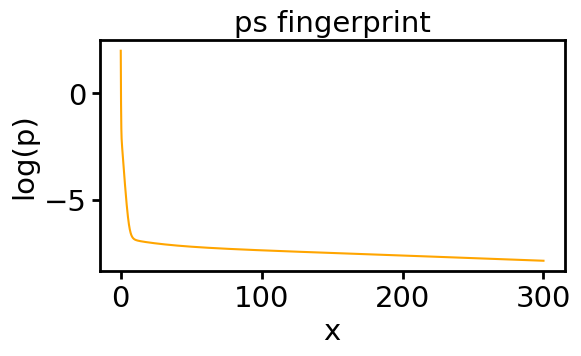

In [ ]:
x = np.linspace(0, 300, 3000)
p_ps_fingerprint = pdf_tar(x)
log_p_ps_fingerprint = np.log(p_ps_fingerprint)
T_ps_fingerprint = 1/np.sqrt(p_ps_fingerprint)

dx = 0.1

first_deriv_ps_fingerprint = np.gradient(p_ps_fingerprint, dx)
first_deriv_ps_fingerprint_2 = model.dpdf(x)
second_deriv_ps_fingerprint = np.gradient(first_deriv_ps_fingerprint, dx)
second_deriv_ps_fingerprint_2 = model.ddpdf(x)

first_deriv_log = np.gradient(log_p_ps_fingerprint, dx)
second_deriv_log = np.gradient(first_deriv_log, dx)

first_deriv_T = np.gradient(T_ps_fingerprint, dx)
second_deriv_T = np.gradient(first_deriv_T, dx)

pos_ps_fingerprint = np.where(second_deriv_ps_fingerprint > 0)[0]
pos_log = np.where(second_deriv_log > 0)[0]
pos_T = np.where(second_deriv_T > 0)[0]

print(f'{pos_ps_fingerprint.size} of {second_deriv_ps_fingerprint.size} of pdf are positive, '
       f'{pos_log.size} of {second_deriv_log.size} of log pdf are positive, '
       f'{pos_T.size} of {second_deriv_T.size} of T are positive')


ax = fi.universal_figure(data=[x, log_p_ps_fingerprint], color='orange', ylabel='log(p)', 
                         title='ps fingerprint')

## <a id='toc1_3_'></a>[Rejection sampling](#toc0_)
used method as described in https://jaketae.github.io/study/rejection-sampling/

In [11]:
from scipy.stats import weibull_min
def rejection_sampling(pdf, batch, seed):
    """
    """
    x = np.linspace(0, 1000, 10000)
    K = np.max(pdf(x) / weibull_min.pdf(x, c=0.1))
    
    rng = np.random.default_rng(seed)

    x_sampled = weibull_min.rvs(size=batch, c=0.1)
    y_sampled = rng.uniform(low=0, high=K*weibull_min.pdf(x_sampled, c=0.1), size=batch)
    mask = pdf(x_sampled) > y_sampled
    
    return x_sampled[mask], K

The expected number of trials to generate one variate is the ratio between the area below the hat and the area below the density. If both functions are originally pdfs, their integral is 1, and the hat function is scaled by K, then its integral is also scaled by K, meaning K rejections before acceptence

In [12]:
samples, k = rejection_sampling(pdf_tar, int(1e6), 1)

WARNING for line:         return c*pow(x, c-1)*np.exp(-pow(x, c))
 divide by zero encountered in power 


array([[<Axes: xlabel='x', ylabel='y'>]], dtype=object)

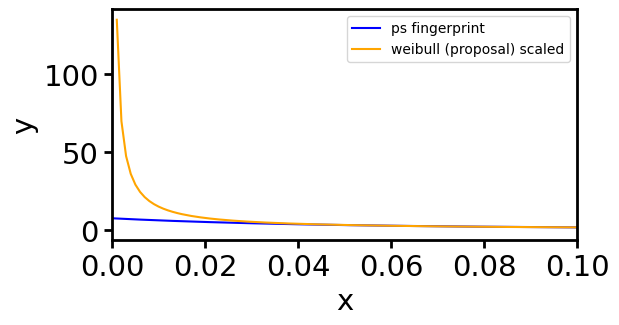

In [14]:
x = np.linspace(0, 1, 1000)
ax = fi.universal_figure(data=[x, pdf_tar(x)], label='ps fingerprint')
fi.universal_figure(data=[x, weibull_min.pdf(x, c=0.1)*k], label='weibull (proposal) scaled', 
                    axes=ax, legend=True, xlim=[0, 0.1], color='orange')

array([[<Axes: title={'center': 'rejection sampling'}, xlabel='x', ylabel='y'>]],
      dtype=object)

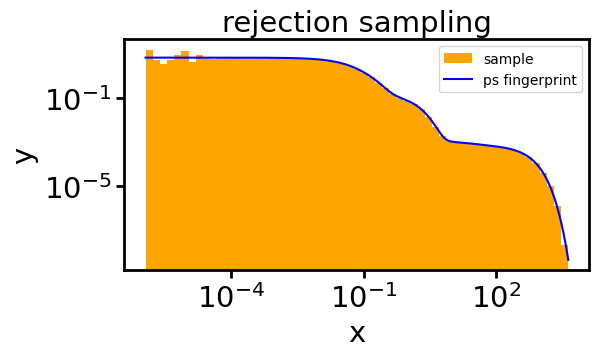

In [16]:
x = np.logspace(np.log10(np.min(samples)), np.log10(np.max(samples)), 1000)
bins = np.logspace(np.log10(np.min(samples)), np.log10(np.max(samples)), 60)
ax = fi.universal_figure(type_='hist', data=[samples], bins=bins, color='orange', ylabel='counts', xlabel='x', 
                         title='rejection sampling', density=True, label='sample')
fi.universal_figure(data=[x, pdf_tar(x)], label='ps fingerprint', axes=ax, legend=True, color='blue',
                    xscale='log', yscale='log')

We can check whether the samples, statistically speaking, follow the distribution, using kstest. If the p value is large enough, one does not reject the null hypothesis. The null hypothesis is that the sample follows the given distribution. 

In [17]:
p = kstest(samples, cdf_tar)[1]
print(f'if p value > 0.05, sampling was successfull. p-value: {p}')
if p < 0.05:
    print('Sampling was not successfull.')
else:
    print('Sampling was successfull.')

if p value > 0.05, sampling was successfull. p-value: 0.16656537287971462
Sampling was successfull.


Problem of rejection sampling: finding a good proposal distribution

## <a id='toc1_4_'></a>[Ratio of Uniforms (RoU)](#toc0_)
Challenge: Correctly define umax, vmin, vmax \
$umax = \sup \sqrt{p(x)}$ \
$vmin = \inf x * \sqrt{p(x)}$ \
$vmax = \sup x * \sqrt{p(x)}$ \
Note: typically there is a shift parameter mu or c, however for most distributions it should be set to 0 or the mode of the distribution, which in this case is also 0.

In [27]:
# the infimum of x * sqrt(pdf) is 0 (at x=0), because the pdf is defined on [0, inf)
vmin = 0

In [23]:
# the supremum of sqrt(pdf) is at x = mode
# here, the mode is 0, so supremum is sqrt(pdf(0))
umax = np.sqrt(pdf_tar(0))

# x = 0 can be seen with:
def function_to_minimize(x, pdf, ):
    return pdf(x) * -1

x0s = [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6]
x_minima = []
for x0 in x0s:
    x_min = minimize(function_to_minimize, x0=x0, args=(pdf_tar),
                     bounds=Bounds(0, np.inf)).x
    x_minima.append(x_min)
x_minima = np.array(x_minima)
a = pdf_tar(x_minima)
x_minimum = x_minima[np.argmin(-1 * pdf_tar(x_minima))]
x_max = x_minimum
print(f'The mode is at x = {x_max}')

print(f'{umax = }')

The mode is at x = [0.]
umax = np.float64(2.725068806470765)


In [25]:
# the supremum of x * sqrt(pdf) has to be identified 
# this can be done by finding where the minimum of -x * sqrt(pdf) is
# note that the function to minimize can have multiple minima
def function_to_minimize(x, pdf):
    return x * np.sqrt(pdf(x)) * -1
x0s = [0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6]
x_minima = []
for x0 in x0s:
    x_min = minimize(function_to_minimize, x0=x0, args=(pdf_tar),
                     bounds=Bounds(0, np.inf)).x
    x_minima.append(x_min)
y_max = np.max([x * np.sqrt(pdf_tar(x)) for x in x_minima])
vmax = y_max

print(f'{vmax = }')

vmax = np.float64(8.204103765410919)


In [28]:
num_rejections = 2 * umax * (vmax - vmin)  # since pdf integral is 1
print(f'Number of rejections before acceptance: {num_rejections}')
RoU = sampling.RatioUniforms(pdf=pdf_tar, umax=umax, vmin=vmin, vmax=vmax)
samples = RoU.rvs(size=int(1e6))

Number of rejections before acceptance: 44.713494512341285


array([[<Axes: title={'center': 'RoU'}, xlabel='x', ylabel='y'>]],
      dtype=object)

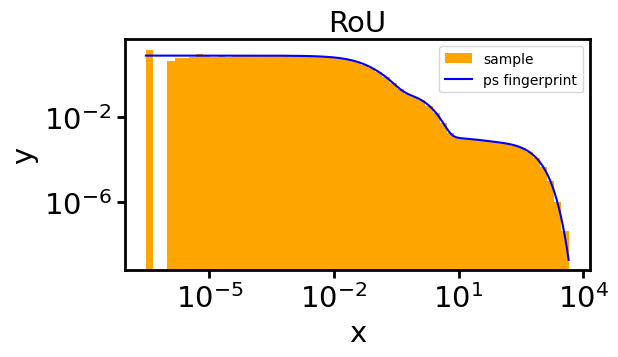

In [29]:
x = np.logspace(np.log10(np.min(samples)), np.log10(np.max(samples)), 1000)
bins = np.logspace(np.log10(np.min(samples)), np.log10(np.max(samples)), 60)
ax = fi.universal_figure(type_='hist', data=[samples], bins=bins, color='orange', ylabel='counts', xlabel='x', 
                         title='RoU', density=True, label='sample')
fi.universal_figure(data=[x, pdf_tar(x)], label='ps fingerprint', axes=ax, legend=True, color='blue',
                    xscale='log', yscale='log')

In [ ]:
p = kstest(samples, cdf_tar)[1]
print(f'if p value > 0.05, sampling was successfull. p-value: {p}')
if p < 0.05:
    print('Sampling was not successfull.')
else:
    print('Sampling was successfull.')

if p value > 0.05, sampling was successfull. p-value: 0.7127674822981447
Sampling was successfull.


## <a id='toc1_5_'></a>[Numerical inversion](#toc0_)
The interpolating polynomials have to be computed in a setup step. However, it only works for distributions with bounded domain; for distributions with unbounded domain the tails are cut off such that the probability for the tail regions is small compared to the given u-resolution.

The goal of sampling is expected to produce samples in a bounded domain, hence using the truncated distribution (which, indeed, is bounded) would be sufficient.

#### <a id='toc1_5_1_1_'></a>[Hermite Inverse CDF HINV](#toc0_)

In [4]:
dist = NumericalInverseHermite(model, order=5, domain=[0, np.inf], u_resolution=1e-7)

In [5]:
samples = dist.rvs(size=int(1e6))

array([[<Axes: title={'center': 'HINV'}, xlabel='x', ylabel='y'>]],
      dtype=object)

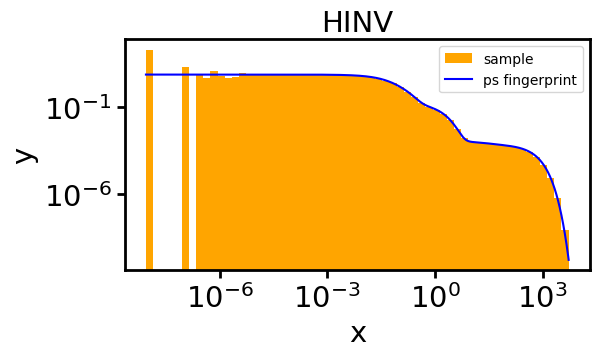

In [6]:
x = np.logspace(np.log10(np.min(samples)), np.log10(np.max(samples)), 1000)
bins = np.logspace(np.log10(np.min(samples)), np.log10(np.max(samples)), 60)
ax = fi.universal_figure(type_='hist', data=[samples], bins=bins, color='orange', ylabel='counts', xlabel='x', 
                         title='HINV', density=True, label='sample')
fi.universal_figure(data=[x, pdf_tar(x)], label='ps fingerprint', axes=ax, legend=True, color='blue',
                    xscale='log', yscale='log')

In [ ]:
p = kstest(samples, cdf_tar)[1]
print(f'if p value > 0.05, sampling was successfull. p-value: {p}')
if p < 0.05:
    print('Sampling was not successfull.')
else:
    print('Sampling was successfull.')

if p value > 0.05, sampling was successfull. p-value: 0.9765072336190969
Sampling was successfull.


#### <a id='toc1_5_1_2_'></a>[Polynomial inverse CDF](#toc0_)

In [37]:
dist = NumericalInversePolynomial(model, order=5, domain=[0, np.inf], u_resolution=1e-5, mode=0)

In [38]:
samples = dist.rvs(size=int(1e6))

array([[<Axes: title={'center': 'PINV'}, xlabel='x', ylabel='y'>]],
      dtype=object)

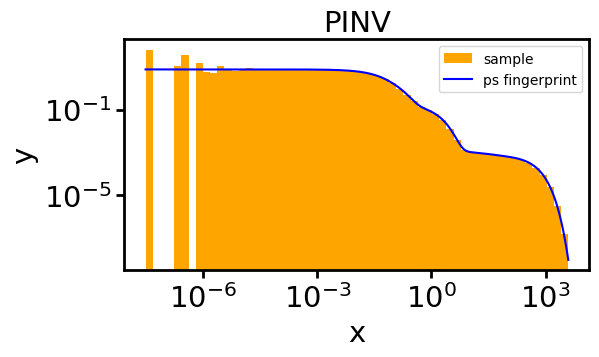

In [40]:
x = np.logspace(np.log10(np.min(samples)), np.log10(np.max(samples)), 1000)
bins = np.logspace(np.log10(np.min(samples)), np.log10(np.max(samples)), 60)
ax = fi.universal_figure(type_='hist', data=[samples], bins=bins, color='orange', ylabel='counts', xlabel='x', 
                         title='PINV', density=True, label='sample')
fi.universal_figure(data=[x, pdf_tar(x)], label='ps fingerprint', axes=ax, legend=True, color='blue',
                    xscale='log', yscale='log')

In [ ]:
p = kstest(samples, cdf_tar)[1]
print(f'if p value > 0.05, sampling was successfull. p-value: {p}')
if p < 0.05:
    print('Sampling was not successfull.')
else:
    print('Sampling was successfull.')

if p value > 0.05, sampling was successfull. p-value: 0.00498815556776128
Sampling was not successfull.


## <a id='toc1_6_'></a>[Conclusion](#toc0_)
HINV (numerical inverse hermite) is the best option here due to the least error-prone setup step (setup steps have to done for each parameter set). Especially when considering that the target distribution will be most likely bounded in the domain (i.e., samples will be drawn between 0 and non-infinity). Also, order=5 is available due to analytical expression of CDF, PDF and dPDf. The u-resolution can be set quite low such that it doesn't significantly deviate from resultion the underlying uniform random number sampling. 

Ratio Of Uniforms requires finding a global maximum which is error-prone and the setup takes quite long.

An automatic setup of rejection sampling such that K is minimized will be difficult to implement for a non-concave function and even if successful, the setup step will be time consuming.